<a href="https://colab.research.google.com/github/lauraemmanuella/prog2/blob/main/PilaresOO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pilares da Orientação a Objetos


---

O que vamos ver aqui?

1. Abstração
2. Encapsulamento
3. Herança
4. Polimorfismo de sobreposição de métodos
5. Exercícios

# Abstração

> Diminuição da complexidade do problema, retirando detalhes de menor importância para um determinado contexto

Como usamos abstração na Programação Orientada a Objetos?

* Quando definimos as classes que modelam o problema, nos concentramos apenas nas características que importam para o **programa**, desconsiderando toda a **complexidade real** daquela classe de objetos

* **Abstrair = relevar aquilo que não importa naquele momento**

Vamos usar o exemplo da implementação de um sistema bancário: Quando definimos as classes que fazem parte do sistema, precisamos abstrair detalhes do sistema bancário real e que não precisam estar no programa.

In [ ]:
class Conta:

  #essa variável de classe será usada para gerar os números das contas automaticamente
  numAtual = 0  

  def __init__(self, valor = 0):
    self.saldo = valor
    Conta.numAtual += 1
    self.numero = Conta.numAtual
    print(f'\nConta número {self.numero} criada com sucesso')
  
  def __str__(self):
    return f'Conta número: {self.numero} Saldo: R$ {self.saldo}'

  def deposito(self, valor):
    self.saldo = self.saldo + valor
    print(f'\nDepósito realizado com sucesso. Saldo atual = {self.saldo}')
  
  def saque(self, valor):
    if self.saldo >= valor:
      self.saldo = self.saldo - valor
      print(f'\nSaque realizado com sucesso. Saldo atual = {self.saldo}')
    else:
      print('\nSaldo insuficiente')

In [ ]:
c1 = Conta() #objeto de Conta
print(c1)


Conta número 1 criada com sucesso
Conta número: 1 Saldo: R$ 0


In [ ]:
Conta.numAtual

1

In [ ]:
c1.deposito(50)


Depósito realizado com sucesso. Saldo atual = 50


In [ ]:
c1.saque(100)


Saldo insuficiente


In [ ]:
c1.saque(20)


Saque realizado com sucesso. Saldo atual = 30


In [ ]:
print(c1)

Conta número: 1 Saldo: R$ 30


# Encapsulamento

> Encapsular em orientação a objetos é ocultar atributos e métodos de uma classe, deixando-os acessíveis apenas dentro da própria classe.

**O Objetivo principal é evitar pontos de falha**

No exemplo da classe Conta, a variável de classe numAtual é usada na atribuição dos números das contas. Ela não tem utilidade fora da classe e para evitar alterações indevidas no seu valor, deve ficar invisível fora da classe.

> Para encapsular um elemento (atributo, método, variável de classe, etc.) de uma classe em Python colocamos duplo underscore no começo do nome do elemento que se quer ocultar.

Observe no exemplo da classe Conta que vamos ocultar a variável de classe numAtual, colocando duplo underscore no começo do nome da variável.

In [ ]:
class Conta:

  __numAtual = 0 #Variável encapsulada (oculta fora da classe)

  def __init__(self, valor = 0):
    self.saldo = valor
    Conta.__numAtual += 1
    self.numero = Conta.__numAtual
    print(f'\nConta número {self.numero} criada com sucesso')
  
  def __str__(self):
    return f'Conta número: {self.numero} Saldo: R$ {self.saldo}'

  def deposito(self, valor):
    self.saldo = self.saldo + valor
    print(f'\nDepósito realizado com sucesso. Saldo atual = {self.saldo}')
  
  def saque(self, valor):
    if self.saldo >= valor:
      self.saldo = self.saldo - valor
      print(f'\nSaque realizado com sucesso. Saldo atual = {self.saldo}')
    else:
      print('\nSaldo insuficiente')

In [ ]:
c1 = Conta(10)
print(c1)


Conta número 1 criada com sucesso
Conta número: 1 Saldo: R$ 10


In [ ]:
Conta.__numAtual #O encapsulamento não permite ver a variável fora da classe

AttributeError: ignored

### Exercício

Altere a classe conta para que o saldo torne-se um atributo privado da classe, ou seja, sem acesso externo. Teste a alteração feita.

# Herança

Quando precisamos definir uma classe que possui características e funcionalidades parecidas com outra classe já implementada, podemos reaproveitar o código já escrito e adicionar outras características e funcionalidades específicas da nova classe

**Esse processo é chamado de herança**

> Quer dizer que a nova classe HERDA o código da classe já definida e ESTENDE seu código para adicionar novas características e funcionalidades específicas


* A classe originária é chamada de MÃE ou SUPERCLASSE ou classe BASE 
* A classe construída a partir da outra é chamada de FILHA ou SUBCLASSE

> Esse processo se dá pelo fato de que a classe filha herda os atributos e métodos da classe mãe

Em Python, para dizer que uma classe será filha de outra, colocamos o nome da classe BASE dentro de parânteses junto ao nome da classe sendo criada (veja exemplo abaixo)

No __init__ da classe FILHA temos que chamar o __init__ da classe MÃE para inicializar os atributos definidos lá (observe o exemplo abaixo)

**Os atributos e métodos encapsulados da classe mãe não ficam visíveis na classe filha**

**Conta corrente**

In [ ]:
class Corrente(Conta):

  def __init__(self, t, valor = 0):
    Conta.__init__(self, valor) 
    self.tarifa = t

  def debitaTarifa(self):
    self.saldo = self.saldo - self.tarifa

In [ ]:
cc1 = Corrente(t = 49.90)
print(cc1)


Conta número 2 criada com sucesso
Conta número: 2 Saldo: R$ 0


In [ ]:
cc1.deposito(1000)


Depósito realizado com sucesso. Saldo atual = 1000


In [ ]:
cc1.saque(30)


Saque realizado com sucesso. Saldo atual = 970


**Conta poupança**

In [ ]:
class Poupanca(Conta):

  def __init__(self, r, valor = 0):
    Conta.__init__(self, valor)
    self.rendimento = r

  def creditarRendimento(self):
    self.saldo = self.saldo + self.rendimento * self.saldo

In [ ]:
cp1 = Poupanca(r = 0.05)
print(cp1)


Conta número 3 criada com sucesso
Conta número: 3 Saldo: R$ 0


In [ ]:
cp1.deposito(1000)


Depósito realizado com sucesso. Saldo atual = 1000


In [ ]:
cp1.creditarRendimento()

In [ ]:
print(cp1)

Conta número: 3 Saldo: R$ 1050.0


# Sobreposição de métodos

> Chamamos de sobreposição de método, quando a classe filha define um método com o mesmo nome e parâmetros de um método já definido na classe mãe. Nesse caso, quando chamamos o método a partir de um objeto da classe filha, o método executado é o definido nela (classe filha).

Observe no exemplo abaixo que o método __str__ será definido na classe Poupança, mas ele já existe na classe Conta. Nesse caso, quando mandamos printar o objeto de Poupança, o __str__ chamado é o que foi implementado nela.

In [ ]:
class Poupanca(Conta):

  def __init__(self, r, valor = 0):
    Conta.__init__(self, valor)
    self.rendimento = r

  def creditarRendimento(self):
    self.saldo = self.saldo + self.rendimento * self.saldo

  def __str__(self):
    return Conta.__str__(self) + ' Tipo: Poupança' 

In [ ]:
cp2 = Poupanca(r = 0.05, valor = 1200)
print(cp2)


Conta número 4 criada com sucesso
Conta número: 4 Saldo: R$ 1200 Tipo: Poupança


> Observe que podemos chamar os métodos da classe mãe dentro da classe filha usando o nome da classe mãe e passando o self como parâmetro, como no exemplo acima

Outra forma de fazer isso é usando o método super(), como abaixo:

In [ ]:
class Poupanca(Conta):

  def __init__(self, r, valor = 0):
    super().__init__(valor)
    self.rendimento = r

  def creditarRendimento(self):
    self.saldo = self.saldo + self.rendimento * self.saldo

  def __str__(self):
    return super().__str__() + ' Tipo: Poupança' 

In [ ]:
cp3 = Poupanca(r = 0.05, valor = 1200)
print(cp3)


Conta número 5 criada com sucesso
Conta número: 5 Saldo: R$ 1200 Tipo: Poupança


# Exercícios


---



**Questão 1.**

Implemente uma classe Pessoa com os atributos: nome, email e telefone recebidos no init. Defina o método str que mostre os atributos do objeto.

Implemente duas classes filhas da classe Pessoa: Cliente e Funcionários. A classe Cliente terá o atributo pontos, enquanto Funcionário terá o atributo Salário. Defina str nas classes filhas para acrescentar informação além das que são mostradas no str da classe Pessoa.

Crie objetos das classes criadas e teste o acesso aos atributos e métodos.

**Questão 2:**

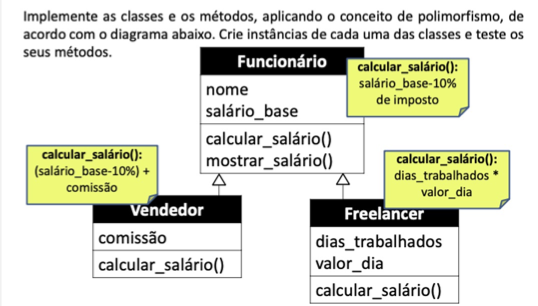